In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('./Datasets/train.csv')
df.head()

,id,Driver,Compound,Race,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change,PitNextLap
0,0,D109,HARD,Canadian Grand Prix,2022,0,50,2,39.0,8,78.491,-7.564,21.019,0.714286,5.0,1.0
1,1,D086,HARD,Dutch Grand Prix,2025,1,27,2,7.0,4,75.095,-32.617,-223.207,0.346154,-3.0,0.0
2,2,ZON,HARD,Austrian Grand Prix,2022,0,59,3,22.0,13,70.945,-7.540,-100.529,0.819444,3.0,1.0
3,3,SPE,MEDIUM,Pre-Season Testing,2023,0,2,1,2.0,7,94.361,-7.324,-7.324,0.076923,0.0,0.0
4,4,D019,HARD,Azerbaijan Grand Prix,2022,1,26,3,6.0,2,107.878,8.965,-14.139,0.361111,3.0,0.0


In [4]:
df.shape

(439140, 16)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 439140 entries, 0 to 439139
Data columns (total 16 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   id                      439140 non-null  int64  
 1   Driver                  439140 non-null  str    
 2   Compound                439140 non-null  str    
 3   Race                    439140 non-null  str    
 4   Year                    439140 non-null  int64  
 5   PitStop                 439140 non-null  int64  
 6   LapNumber               439140 non-null  int64  
 7   Stint                   439140 non-null  int64  
 8   TyreLife                439140 non-null  float64
 9   Position                439140 non-null  int64  
 10  LapTime (s)             439140 non-null  float64
 11  LapTime_Delta           439140 non-null  float64
 12  Cumulative_Degradation  439140 non-null  float64
 13  RaceProgress            439140 non-null  float64
 14  Position_Change         439140 

In [6]:
df.describe()

,id,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change,PitNextLap
count,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000
mean,219569.500000,2023.523544,0.136118,23.105909,1.789113,14.158231,9.630339,90.948735,-3.770040,-25.721759,0.337661,0.101542,0.198982
std,126768.942943,1.024930,0.342915,16.958261,0.950194,9.801338,5.278770,19.772769,43.945759,54.766573,0.253277,4.006765,0.399235
min,0.000000,2022.000000,0.000000,1.000000,1.000000,1.000000,1.000000,67.694000,-2403.895000,-274.564000,0.012821,-18.000000,0.000000
25%,109784.750000,2023.000000,0.000000,9.000000,1.000000,6.000000,5.000000,82.621000,-8.884000,-46.566250,0.129870,-1.000000,0.000000
50%,219569.500000,2024.000000,0.000000,19.000000,2.000000,12.000000,10.000000,90.521000,-0.295000,-20.994000,0.269231,0.000000,0.000000
75%,329354.250000,2024.000000,0.000000,36.000000,2.000000,20.000000,14.000000,98.471000,0.115000,-6.199000,0.513158,2.000000,0.000000
max,439139.000000,2025.000000,1.000000,78.000000,8.000000,77.000000,20.000000,2507.607000,2423.932000,2412.026000,1.000000,18.000000,1.000000


In [7]:
# unique values in each column
df.nunique()

id                        439140
Driver                       887
Compound                       5
Race                          26
Year                           4
PitStop                        2
LapNumber                     78
Stint                          8
TyreLife                      78
Position                      20
LapTime (s)                37719
LapTime_Delta              57532
Cumulative_Degradation    142701
RaceProgress                1898
Position_Change               37
PitNextLap                     2
dtype: int64

In [8]:
# finding unique values in stint column
df['Stint'].unique()

array([2, 3, 1, 4, 5, 6, 8, 7])

In [9]:
# finding unique values in compound column
df['Compound'].unique()

<StringArray>
['HARD', 'MEDIUM', 'INTERMEDIATE', 'SOFT', 'WET']
Length: 5, dtype: str

In [10]:
df['LapNumber'].unique()

array([50, 27, 59,  2, 26, 35, 23, 41,  4, 24,  8,  1, 38,  5, 44, 17, 12,
       16,  3, 36, 11, 28, 33, 15, 22, 31,  6, 43, 30, 39, 51, 10,  7, 34,
       13, 48, 19, 46, 21, 25,  9, 32, 47, 18, 40, 29, 37, 57, 67, 56, 52,
       14, 20, 62, 61, 54, 74, 49, 69, 64, 42, 55, 58, 66, 60, 68, 45, 53,
       76, 72, 63, 65, 70, 71, 75, 73, 77, 78])

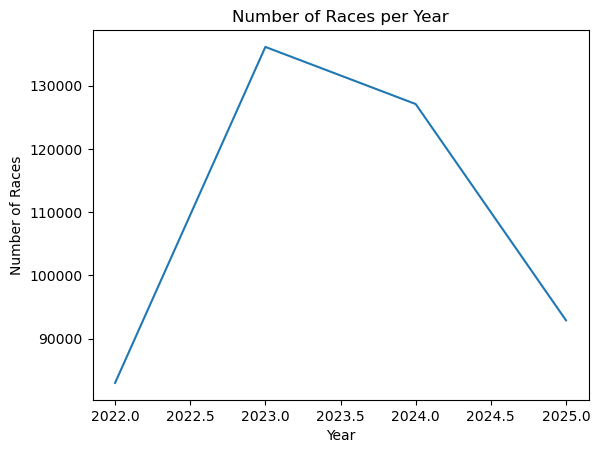

In [11]:
# no of races in each year with their line chart
df['Year'].value_counts().sort_index().plot(kind='line')
plt.title('Number of Races per Year')
plt.xlabel('Year')
plt.ylabel('Number of Races')
plt.show()

In [13]:
# no of races driver D109 has used different compounds in year 2023 and its relation with PitNextLap.
df[df['Driver'] == 'D109'].groupby(['Year', 'Compound'])['PitNextLap'].value_counts().unstack()

PitNextLap           0.0   1.0
Year Compound                 
2022 HARD           19.0  13.0
     INTERMEDIATE    1.0   NaN
     MEDIUM         97.0  28.0
     SOFT           10.0   8.0
     WET             2.0   NaN
2023 HARD          140.0   2.0
     MEDIUM        148.0   NaN
     SOFT           38.0   NaN
2024 HARD           45.0  76.0
     INTERMEDIATE   10.0   1.0
     MEDIUM        148.0   8.0
     SOFT           15.0   3.0
2025 HARD           44.0  38.0
     MEDIUM         97.0  26.0
     SOFT            9.0   4.0

In [14]:
# relation of different drivers with PitNextLap 
df.groupby(['Driver'])['PitNextLap'].value_counts().unstack()

PitNextLap,0.0,1.0
Driver,,
ALB,913.0,433.0
ALE,1132.0,319.0
ALG,1181.0,346.0
ALO,841.0,545.0
AND,1173.0,288.0
...,...,...
WIL,1109.0,283.0
WUR,1119.0,294.0
YAM,1143.0,312.0


In [12]:
# no pit v/s pit as percentage also
df['PitNextLap'].value_counts(normalize=True) * 100

PitNextLap
0.0    80.10179
1.0    19.89821
Name: proportion, dtype: float64

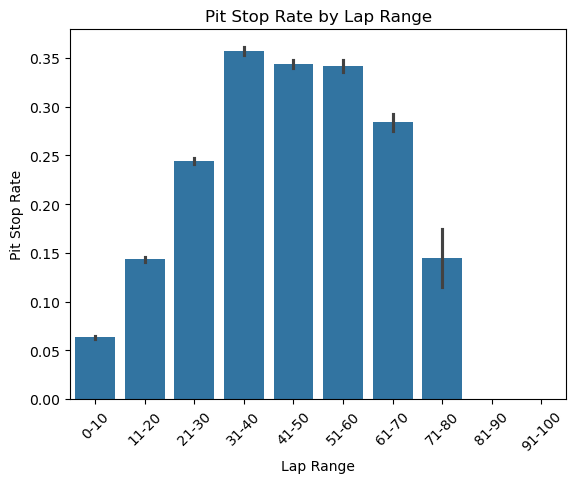

In [13]:
# plot pit rate by lap number in ranges for better view
df['LapRange'] = pd.cut(df['LapNumber'], bins=[0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100], labels=['0-10', '11-20', '21-30', '31-40', '41-50', '51-60', '61-70', '71-80', '81-90', '91-100'])
sns.barplot(x='LapRange', y='PitNextLap', data=df, estimator=lambda x: sum(x) / len(x))
plt.xticks(rotation=45)
plt.title('Pit Stop Rate by Lap Range')
plt.xlabel('Lap Range')
plt.ylabel('Pit Stop Rate')
plt.show()

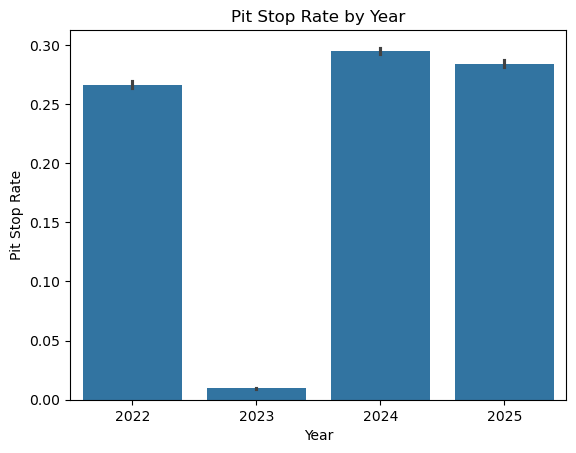

In [17]:
# plot of pit stop rate by year
sns.barplot(x='Year', y='PitNextLap', data=df, estimator=lambda x: sum(x) / len(x))
plt.title('Pit Stop Rate by Year')
plt.xlabel('Year')
plt.ylabel('Pit Stop Rate')
plt.show()

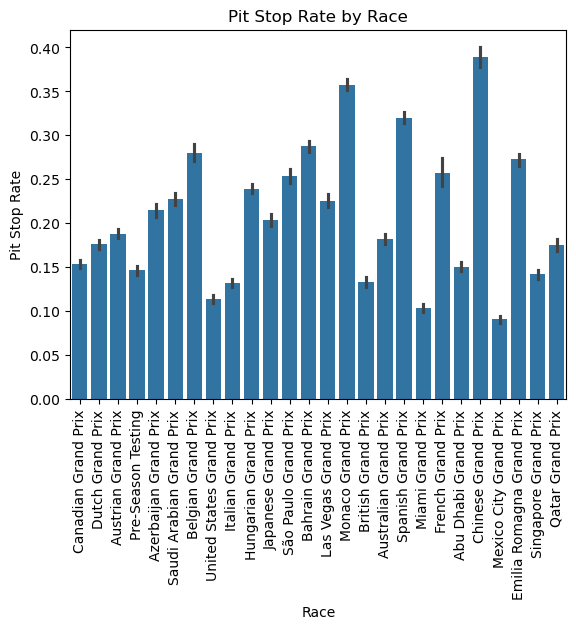

In [18]:
# plot of pit stop rate by race
sns.barplot(x='Race', y='PitNextLap', data=df, estimator=lambda x: sum(x) / len(x))
plt.title('Pit Stop Rate by Race')
plt.xlabel('Race')
plt.ylabel('Pit Stop Rate')
plt.xticks(rotation=90)
plt.show()   

In [14]:
# verify if PitStop=1 and PitNextLap=1 can co-occur
df[(df['PitStop'] == 1) & (df['PitNextLap'] == 1)]

,id,Driver,Compound,Race,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change,PitNextLap,LapRange
29,29,GUT,MEDIUM,Belgian Grand Prix,2025,1,12,2,7.0,20,123.963,42.248,-15.988,0.157895,-4.0,1.0,11-20
43,43,D054,HARD,Japanese Grand Prix,2025,1,33,2,15.0,3,91.978,-4.888,-117.292,0.423077,-2.0,1.0,31-40
75,75,D049,HARD,Singapore Grand Prix,2024,1,48,2,29.0,4,97.679,-10.142,-33.879,0.615385,1.0,1.0,41-50
191,191,D003,HARD,Pre-Season Testing,2024,1,46,2,23.0,10,98.945,-0.898,-19.953,0.638889,-2.0,1.0,41-50
224,224,D290,HARD,Mexico City Grand Prix,2024,1,44,2,11.0,6,80.837,-17.548,-25.704,0.564103,-2.0,1.0,41-50
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
438946,438946,D173,HARD,Austrian Grand Prix,2024,1,12,2,3.0,19,70.580,-8.933,-38.627,0.153846,-15.0,1.0,11-20
438980,438980,D099,HARD,Austrian Grand Prix,2024,1,55,3,16.0,8,70.871,-9.076,-49.900,0.705128,-5.0,1.0,51-60
438983,438983,D124,MEDIUM,Emilia Romagna Grand Prix,2022,1,28,2,14.0,2,78.922,-12.223,-78.203,0.388889,-1.0,1.0,21-30
439046,439046,D065,HARD,Chinese Grand Prix,2025,1,20,2,15.0,13,103.049,19.766,-76.807,0.259740,3.0,1.0,11-20


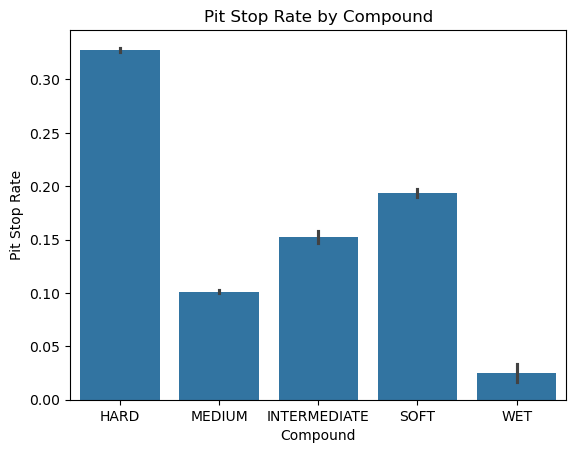

In [20]:
# plot tyrelife vs pitrate for each compound
sns.barplot(x='Compound', y='PitNextLap', data=df, estimator=lambda x: sum(x) / len(x))
plt.title('Pit Stop Rate by Compound')
plt.xlabel('Compound')
plt.ylabel('Pit Stop Rate')
plt.show()   

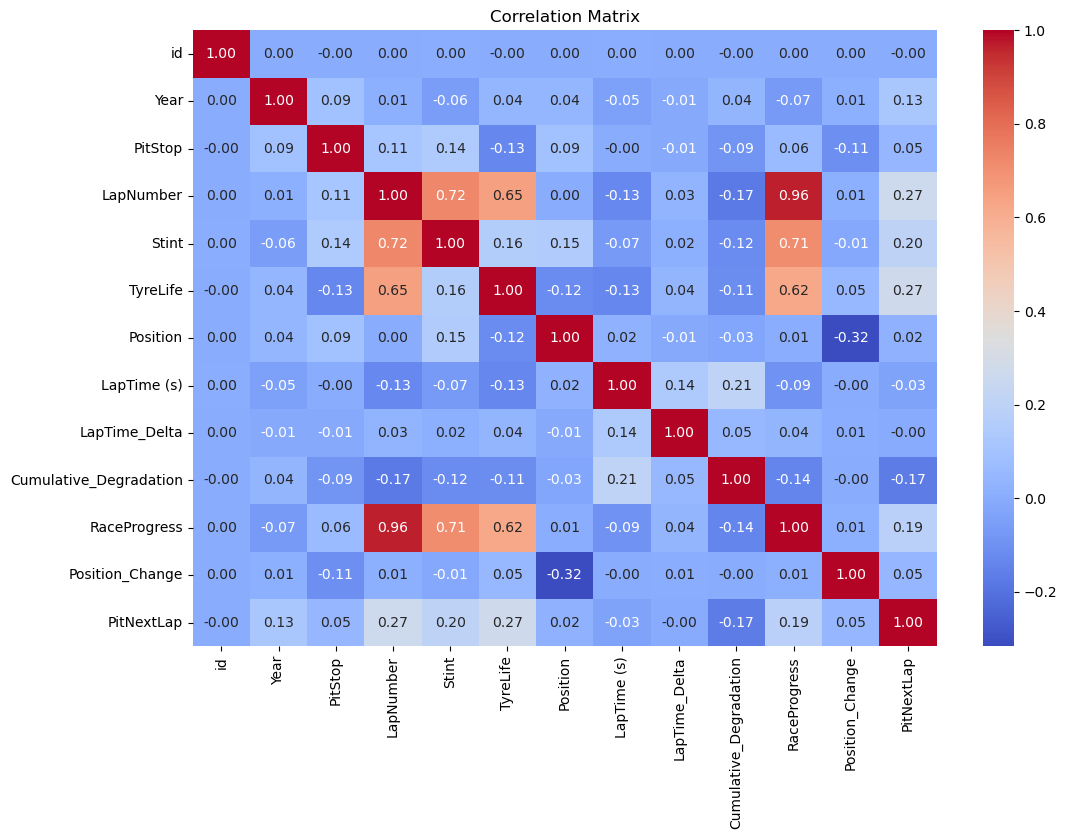

In [21]:
# correlation and multi-collinearity audit for numeric columns with pitnextlap as target variable
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
correlation_matrix = df[numeric_cols].corr()
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

In [22]:
# check if cumulative degradation values is near 0 if PitStop=1
df[df['PitStop'] == 1]['Cumulative_Degradation'].describe()

count    59775.000000
mean       -37.870281
std         62.099239
min       -274.349000
25%        -54.102000
50%        -31.819000
75%        -10.523000
max       2383.678000
Name: Cumulative_Degradation, dtype: float64

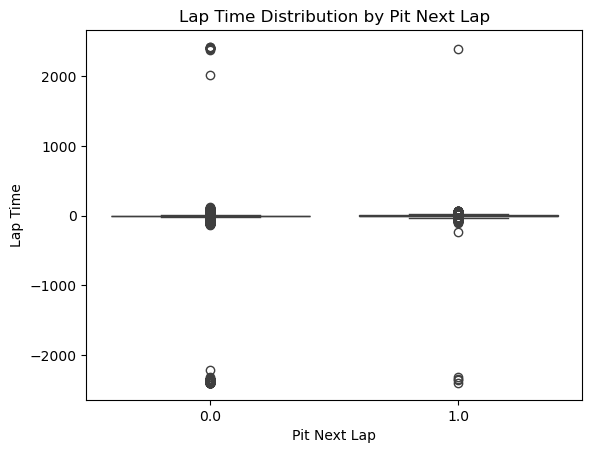

In [23]:
# laptime correlation with pitnextlap with binned plots
sns.boxplot(x='PitNextLap', y='LapTime_Delta', data=df)
plt.title('Lap Time Distribution by Pit Next Lap')
plt.xlabel('Pit Next Lap')
plt.ylabel('Lap Time')
plt.show()

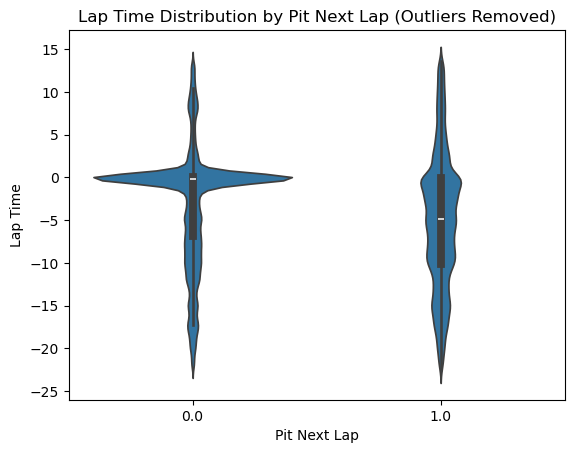

In [24]:
# removing extreme outliers in laptime delta for better view using quantile based filtering
q1 = df['LapTime_Delta'].quantile(0.25)
q3 = df['LapTime_Delta'].quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr
filtered_df = df[(df['LapTime_Delta'] >= lower_bound) & (df['LapTime_Delta'] <= upper_bound)]
sns.violinplot(x='PitNextLap', y='LapTime_Delta', data=filtered_df)
plt.title('Lap Time Distribution by Pit Next Lap (Outliers Removed)')
plt.xlabel('Pit Next Lap')
plt.ylabel('Lap Time')
plt.show()


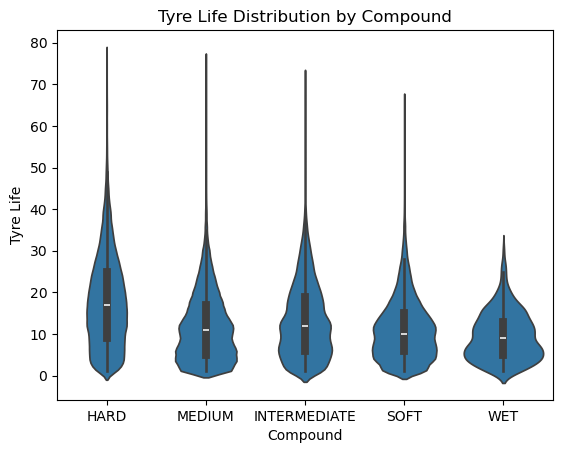

In [25]:
# plot tyrelife distribution for each compound
sns.violinplot(x='Compound', y='TyreLife', data=df)
plt.title('Tyre Life Distribution by Compound')
plt.xlabel('Compound')
plt.ylabel('Tyre Life')
plt.show()

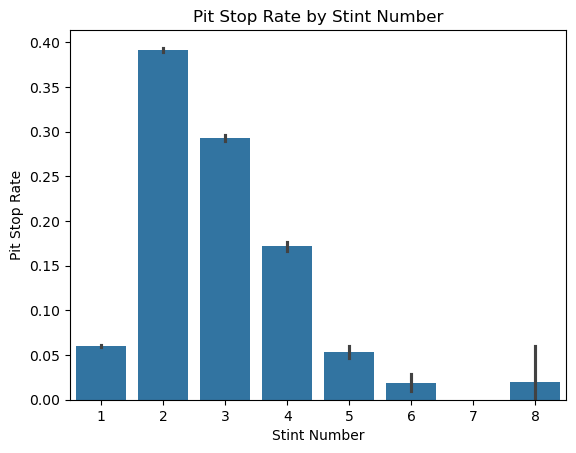

In [26]:
# how stint number affects pitrate 
sns.barplot(x='Stint', y='PitNextLap', data=df, estimator=lambda x: sum(x) / len(x))
plt.title('Pit Stop Rate by Stint Number')
plt.xlabel('Stint Number')
plt.ylabel('Pit Stop Rate')
plt.show()

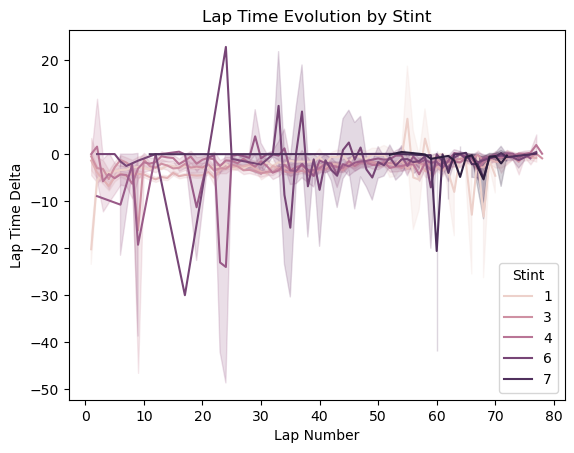

In [27]:
# plot lap-time evolution within a stint
sns.lineplot(x='LapNumber', y='LapTime_Delta', hue='Stint', data=df)
plt.title('Lap Time Evolution by Stint')
plt.xlabel('Lap Number')
plt.ylabel('Lap Time Delta')
plt.show()

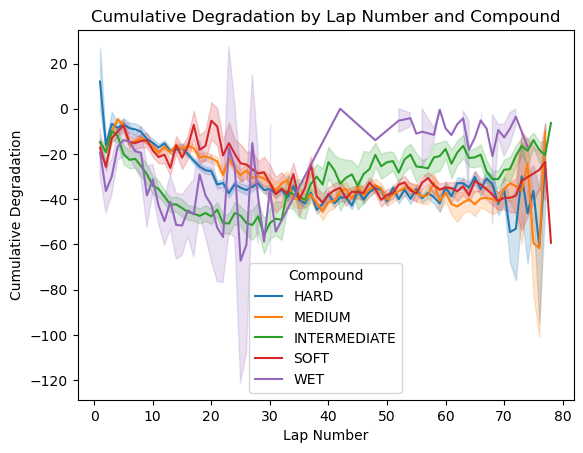

In [28]:
# plot characteristic degradation curve
sns.lineplot(x='LapNumber', y='Cumulative_Degradation', hue='Compound', data=df)
plt.title('Cumulative Degradation by Lap Number and Compound')
plt.xlabel('Lap Number')
plt.ylabel('Cumulative Degradation')
plt.show()

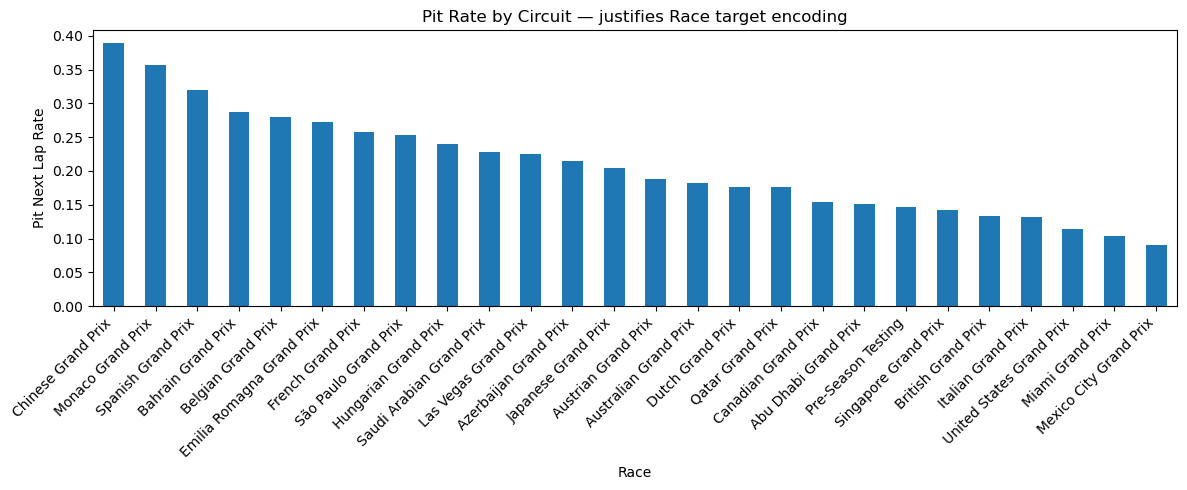

Apply target_encode_with_smoothing(train, val, "Race", "PitNextLap") after splitting.


In [29]:
# Preview the circuit pit rate variation — confirms circuit matters
race_pit_rates = df.groupby('Race')['PitNextLap'].mean().sort_values(ascending=False)
plt.figure(figsize=(12, 5))
race_pit_rates.plot(kind='bar')
plt.title('Pit Rate by Circuit — justifies Race target encoding')
plt.ylabel('Pit Next Lap Rate')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()
print('Apply target_encode_with_smoothing(train, val, "Race", "PitNextLap") after splitting.')

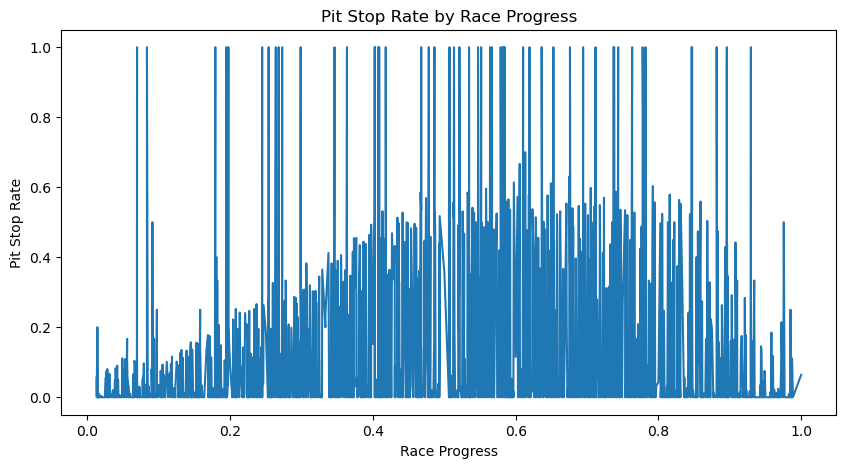

In [15]:
# when do racers pit, what are different windows use raceprogress with pitnextlap
race_progress_pit = df.groupby('RaceProgress')['PitNextLap'].mean()
plt.figure(figsize=(10, 5))
race_progress_pit.plot(kind='line')
plt.title('Pit Stop Rate by Race Progress')
plt.xlabel('Race Progress')
plt.ylabel('Pit Stop Rate')
plt.show()